In [1]:
import pandas as pd

df = pd.read_csv("../data/perfectly_realistic_career_guidance_dataset_1500.csv")

df.head()

,Education_Level,Specialization,Skills,Interests,Recommended_Career,Career_Description
0,B.Com,Finance,"Communication, Tax Filing",Social Work,Financial Analyst,B.Com graduates specialized in Finance with sk...
1,MBA,Marketing,"Leadership, Strategy, Analytics",Management,HR Specialist,MBA graduates specialized in Marketing with sk...
2,BCA,Computer Applications,"Python, Web Development, Databases",Social Work,System Analyst,BCA graduates specialized in Computer Applicat...
3,BA,Political Science,"Writing, Communication",Research,Journalist,BA graduates specialized in Political Science ...
4,BCA,Computer Applications,"Python, Web Development, Databases",Technology,System Analyst,BCA graduates specialized in Computer Applicat...


In [2]:
df.shape

(1500, 6)

In [3]:
df.columns

Index(['Education_Level', 'Specialization', 'Skills', 'Interests',
       'Recommended_Career', 'Career_Description'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Education_Level     1500 non-null   str  
 1   Specialization      1500 non-null   str  
 2   Skills              1500 non-null   str  
 3   Interests           1500 non-null   str  
 4   Recommended_Career  1500 non-null   str  
 5   Career_Description  1500 non-null   str  
dtypes: str(6)
memory usage: 70.4 KB


In [5]:
df.isnull().sum()

Education_Level       0
Specialization        0
Skills                0
Interests             0
Recommended_Career    0
Career_Description    0
dtype: int64

In [6]:
df["Recommended_Career"].value_counts()

Recommended_Career
Lecturer                      81
Teacher                       57
Auditor                       54
AI Engineer                   50
Research Scientist            40
General Practitioner          39
Data Analyst                  35
Financial Analyst             33
Editor                        33
Lab Technician                33
Clerk                         32
School Coordinator            32
Finance Manager               31
Junior Assistant              29
Sales Assistant               29
Doctor                        29
Technician                    28
Software Architect            28
Tutor                         27
Business Analyst              27
AutoCAD Designer              27
Analyst                       27
Data Entry Operator           26
Data Scientist                26
Graphic Designer              25
Marketing Executive           25
Fashion Designer              25
Professor                     25
Content Writer                24
Manager                 

In [7]:
df.nunique()

Education_Level         20
Specialization          37
Skills                  49
Interests               10
Recommended_Career      55
Career_Description    1207
dtype: int64

In [8]:
X = df[
    [
        "Education_Level",
        "Specialization",
        "Skills",
        "Interests"
    ]
]

y = df["Recommended_Career"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1500, 4)
Target shape: (1500,)


In [9]:
for col in ["Education_Level", "Specialization", "Interests"]:
    print(f"\n{col}:")
    print(df[col].unique())


Education_Level:
<StringArray>
[  'B.Com',     'MBA',     'BCA',      'BA',     'PhD',    'B.Ed',   'B.Des',
      'MA',    '10th',  'M.Tech',   'M.Com',     'BBA',    'M.Sc',    'MBBS',
    '12th',     'MCA',    'M.Ed',    'B.Sc', 'Diploma',  'B.Tech']
Length: 20, dtype: str

Specialization:
<StringArray>
[               'Finance',              'Marketing',  'Computer Applications',
      'Political Science',         'Social Science',            'Mathematics',
              'Animation',                'English',                'History',
               'Commerce',       'Computer Science',             'Operations',
             'Management',              'Sociology',               'Taxation',
                     'HR',                'Biology',               'Medicine',
              'Education',    'Information Systems', 'Structural Engineering',
                'Physics',             'Humanities',         'Administration',
                'Science',             'Mechanical',       

In [10]:
print(df["Skills"].unique())

<StringArray>
[           'Communication, Tax Filing',
      'Leadership, Strategy, Analytics',
   'Python, Web Development, Databases',
               'Writing, Communication',
 'Research, Data Analysis, Publication',
                    'Student Mentoring',
             'Sketching, Visualization',
            'Research, Public Speaking',
            'Content Writing, Research',
           'Customer Service, Teamwork',
               'AI, Simulation, MATLAB',
              'Teaching, Communication',
                  'Advanced Excel, GST',
               'Team Management, Excel',
                       'Tax Management',
              'Planning, Communication',
            'Analysis, Experimentation',
     'Diagnosis, Surgery, Patient Care',
                        'Communication',
                 'Excel, Communication',
          'Teaching, Curriculum Design',
               'Programming, AI, Cloud',
            'Typing, Customer Handling',
               'Power Analysis, Python',
  

In [11]:
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
import pandas as pd

In [12]:
# -------------------------------
# 1. One-Hot Encode categorical columns
# -------------------------------

categorical_columns = [
    "Education_Level",
    "Specialization",
    "Interests"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

categorical_encoded = encoder.fit_transform(
    df[categorical_columns]
)

categorical_encoded.shape

(1500, 67)

In [13]:
# Convert comma-separated skill strings into lists

skills_list = df["Skills"].apply(
    lambda x: [skill.strip() for skill in x.split(",")]
)

skills_list.head()

0             [Communication, Tax Filing]
1       [Leadership, Strategy, Analytics]
2    [Python, Web Development, Databases]
3                [Writing, Communication]
4    [Python, Web Development, Databases]
Name: Skills, dtype: object

In [14]:
skill_encoder = MultiLabelBinarizer()

skills_encoded = skill_encoder.fit_transform(skills_list)

skills_encoded.shape

(1500, 75)

In [15]:
skill_encoder.classes_

array(['AI', 'Advanced Excel', 'Analysis', 'Analytics',
       'Assessment Design', 'AutoCAD', 'Basic Accounting',
       'Basic Computer', 'Basic Programming', 'Branding', 'Budgeting',
       'Business Analytics', 'CAD', 'Cloud', 'Communication',
       'Content Writing', 'Creativity', 'Critical Thinking',
       'Curriculum Design', 'Customer Handling', 'Customer Service',
       'Data Analysis', 'Data Collection', 'Data Entry',
       'Database Design', 'Databases', 'Design', 'Design Optimization',
       'Diagnosis', 'Educational Planning', 'Electrical Wiring', 'Excel',
       'Experimentation', 'GST', 'Lab Work', 'Leadership', 'MATLAB',
       'Machine Learning', 'Maintenance', 'Management', 'Negotiation',
       'Observation', 'Office Work', 'PLC', 'PSCAD', 'Patient Care',
       'Photoshop', 'Planning', 'Power Analysis', 'Programming',
       'Project Work', 'Public Speaking', 'Publication', 'Python',
       'Recording', 'Reporting', 'Research', 'Sales',
       'Scientific Writi

In [23]:
# Get proper column names for one-hot encoded categorical features
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

categorical_df = pd.DataFrame(
    categorical_encoded,
    columns=categorical_feature_names,
    index=df.index
)

# Proper column names for skill features
skills_df = pd.DataFrame(
    skills_encoded,
    columns=[f"Skill_{skill}" for skill in skill_encoder.classes_],
    index=df.index
)

# Combine both
X_encoded = pd.concat(
    [categorical_df, skills_df],
    axis=1
)

print("Encoded shape:", X_encoded.shape)
print("Duplicate columns:", X_encoded.columns.duplicated().sum())

Encoded shape: (1500, 142)
Duplicate columns: 0


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1200, 142)
Testing data: (300, 142)


In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](55,)","['AI Engineer','Academic Coordinator','Accountant',...,'Tutor', 'Web Developer','Writer']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [26]:
y_pred = knn.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.33


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

for k, acc in zip(k_values, accuracies):
    print(f"K = {k}, Accuracy = {acc * 100:.2f}%")

K = 1, Accuracy = 31.33%
K = 2, Accuracy = 34.33%
K = 3, Accuracy = 34.00%
K = 4, Accuracy = 32.00%
K = 5, Accuracy = 33.00%
K = 6, Accuracy = 33.67%
K = 7, Accuracy = 32.33%
K = 8, Accuracy = 30.33%
K = 9, Accuracy = 31.00%
K = 10, Accuracy = 31.67%
K = 11, Accuracy = 32.00%
K = 12, Accuracy = 34.33%
K = 13, Accuracy = 32.00%
K = 14, Accuracy = 32.67%
K = 15, Accuracy = 33.00%
K = 16, Accuracy = 35.00%
K = 17, Accuracy = 37.33%
K = 18, Accuracy = 35.33%
K = 19, Accuracy = 36.00%
K = 20, Accuracy = 36.67%
K = 21, Accuracy = 37.67%
K = 22, Accuracy = 39.33%
K = 23, Accuracy = 35.33%
K = 24, Accuracy = 39.33%
K = 25, Accuracy = 38.00%
K = 26, Accuracy = 39.33%
K = 27, Accuracy = 37.00%
K = 28, Accuracy = 36.33%
K = 29, Accuracy = 36.67%
K = 30, Accuracy = 38.67%


In [30]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy * 100)

Best K: 22
Best Accuracy: 39.33333333333333


Matplotlib is building the font cache; this may take a moment.


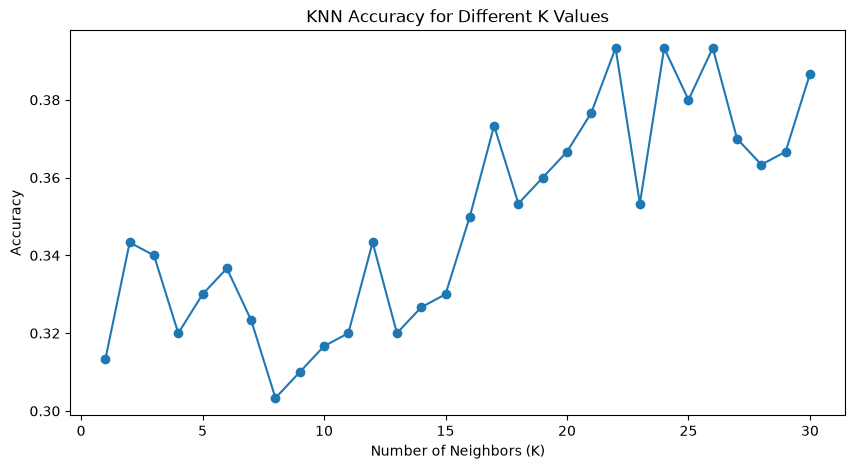

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.show()

In [32]:
final_knn = KNeighborsClassifier(n_neighbors=22)

final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Accuracy: {final_accuracy * 100:.2f}%")

Final Model Accuracy: 39.33%


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

                            precision    recall  f1-score   support

               AI Engineer       0.56      0.50      0.53        10
      Academic Coordinator       0.00      0.00      0.00         4
                Accountant       0.50      0.40      0.44         5
                   Analyst       0.40      0.40      0.40         5
                  Animator       0.43      0.75      0.55         4
         Assistant Manager       0.33      0.40      0.36         5
                   Auditor       0.11      0.09      0.10        11
          AutoCAD Designer       0.43      0.60      0.50         5
          Business Analyst       0.44      0.67      0.53         6
            Civil Engineer       0.50      0.33      0.40         3
                     Clerk       0.50      0.33      0.40         6
                Consultant       0.00      0.00      0.00         4
            Content Writer       0.00      0.00      0.00         5
Customer Support Executive       1.00      0.75

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (55, 55)


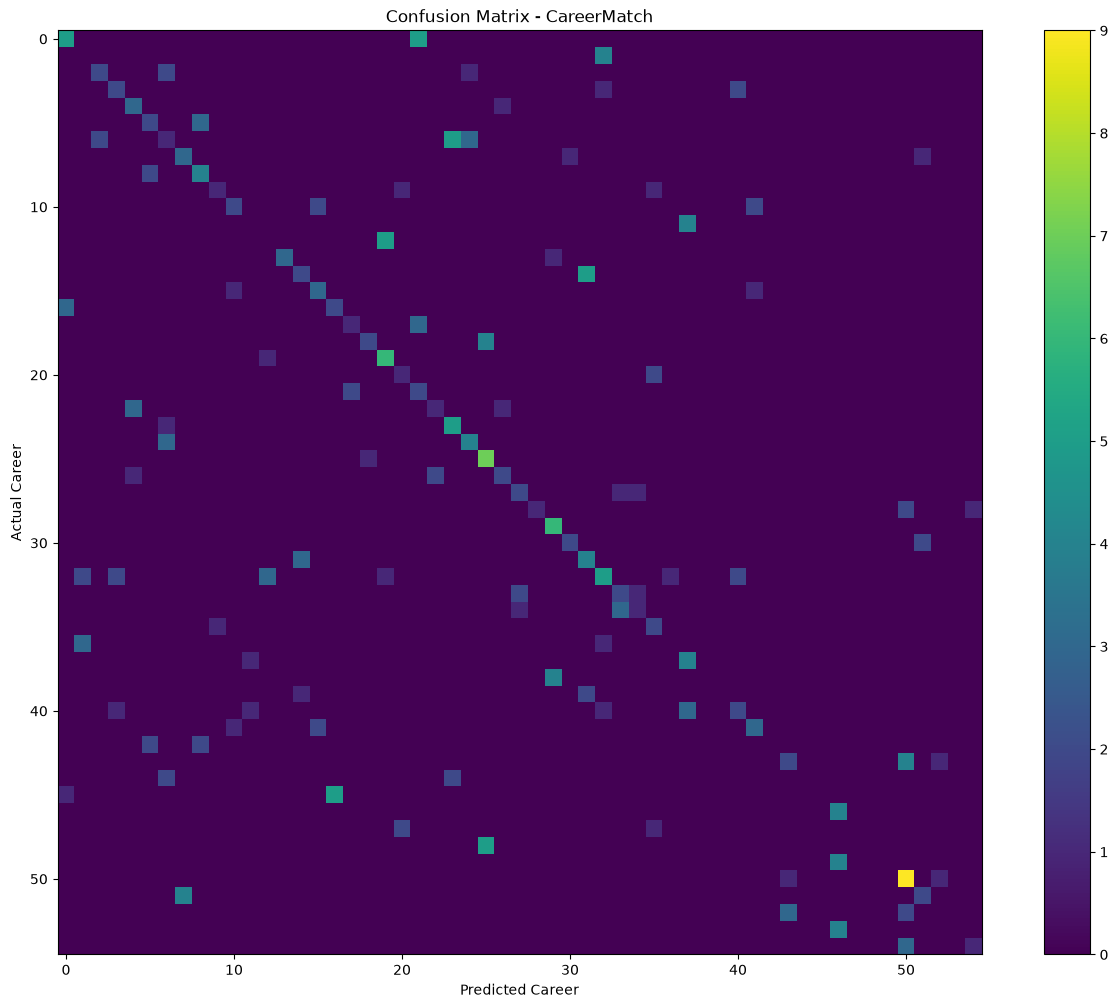

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - CareerMatch")
plt.xlabel("Predicted Career")
plt.ylabel("Actual Career")
plt.colorbar()

plt.show()

In [37]:
import numpy as np

# Get probability scores for each career class
proba = final_knn.predict_proba(X_test)

# Find top 3 predicted classes for each sample
top3_indices = np.argsort(proba, axis=1)[:, -3:][:, ::-1]

top3_predictions = final_knn.classes_[top3_indices]

top3_predictions[:5]

array([['Business Analyst', 'Assistant Manager', 'Sales Executive'],
       ['Finance Manager', 'Auditor', 'Senior Accountant'],
       ['Data Entry Operator', 'Clerk', 'Sales Assistant'],
       ['Business Analyst', 'Assistant Manager', 'Sales Executive'],
       ['Data Scientist', 'Software Architect', 'AI Engineer']],
      dtype=object)

In [38]:
top3_correct = 0

for actual, predicted_list in zip(y_test, top3_predictions):
    if actual in predicted_list:
        top3_correct += 1

top3_accuracy = top3_correct / len(y_test)

print(f"Top-3 Accuracy: {top3_accuracy * 100:.2f}%")

Top-3 Accuracy: 99.33%


In [39]:
from sklearn.metrics import top_k_accuracy_score

top3_builtin = top_k_accuracy_score(
    y_test,
    proba,
    k=3,
    labels=final_knn.classes_
)

print(f"Verified Top-3 Accuracy: {top3_builtin * 100:.2f}%")

Verified Top-3 Accuracy: 99.33%


In [40]:
feature_columns = [
    "Education_Level",
    "Specialization",
    "Skills",
    "Interests"
]

duplicate_profiles = df.duplicated(
    subset=feature_columns,
    keep=False
).sum()

print("Rows with duplicate profiles:", duplicate_profiles)

Rows with duplicate profiles: 932


In [41]:
unique_profiles = df[feature_columns].drop_duplicates().shape[0]

print("Total rows:", len(df))
print("Unique feature profiles:", unique_profiles)

Total rows: 1500
Unique feature profiles: 915


In [42]:
career_counts_per_profile = (
    df.groupby(feature_columns)["Recommended_Career"]
      .nunique()
)

print(
    "Profiles linked to multiple careers:",
    (career_counts_per_profile > 1).sum()
)

Profiles linked to multiple careers: 255


In [43]:
feature_columns = [
    "Education_Level",
    "Specialization",
    "Skills",
    "Interests"
]

profile_groups = (
    df[feature_columns]
    .astype(str)
    .agg(" | ".join, axis=1)
)

print("Unique profile groups:", profile_groups.nunique())

Unique profile groups: 915


In [44]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_encoded, y, groups=profile_groups)
)

X_train = X_encoded.iloc[train_idx]
X_test = X_encoded.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1219
Testing samples: 281


In [45]:
train_profiles = set(profile_groups.iloc[train_idx])
test_profiles = set(profile_groups.iloc[test_idx])

overlap = train_profiles.intersection(test_profiles)

print("Profiles present in both train and test:", len(overlap))

Profiles present in both train and test: 0


In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_grouped = KNeighborsClassifier(n_neighbors=22)

knn_grouped.fit(X_train, y_train)

y_pred = knn_grouped.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Grouped Test Accuracy: {accuracy * 100:.2f}%")

Grouped Test Accuracy: 32.38%


In [47]:
import numpy as np

proba = knn_grouped.predict_proba(X_test)

top3_indices = np.argsort(proba, axis=1)[:, -3:][:, ::-1]

top3_predictions = knn_grouped.classes_[top3_indices]

top3_correct = sum(
    actual in predictions
    for actual, predictions in zip(y_test, top3_predictions)
)

top3_accuracy = top3_correct / len(y_test)

print(f"Grouped Top-3 Accuracy: {top3_accuracy * 100:.2f}%")

Grouped Top-3 Accuracy: 99.64%
